<a href="https://colab.research.google.com/github/myanggg/coffee-ratings-political-leaning/blob/main/Median_household_income_USA_cities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# 1. Read Yelp Data


# Set file path (using absolute path as uploaded to Colab root)
file_path = '/content/drive/MyDrive/yelp/final_fixed_data.csv'

try:
    # Read CSV file
    final_fixed = pd.read_csv(file_path)
    print(f"✅ [Step 1 Success] Yelp data loaded. Total rows: {len(final_fixed)}.")

    # Check columns to ensure 'city' and 'state' exist
    print("Column Check:", final_fixed.columns.tolist())

    # Preview the data
    display(final_fixed.head(3))

except FileNotFoundError:
    print("❌ [Step 1 Failed] File not found! Please check if 'final_fixed_data.csv' is in the file list on the left.")

✅ [Step 1 Success] Yelp data loaded. Total rows: 6325.
Column Check: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours', 'county_std', 'county_name', 'party', 'county_fips']


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,county_std,county_name,party,county_fips
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,Pennsylvania,19107.0,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Philadelphia,Philadelphia,Democrat,NaN
1,lk9IwjZXqUMqqOhM774DtQ,Caviar & Bananas,2031 Broadway,Nashville,Tennessee,37203.0,36.148371,-86.798895,3.5,159,0,"{'RestaurantsTakeOut': 'True', 'RestaurantsRes...","Coffee & Tea, Restaurants, Wine Bars, Bars, Ni...","{'Monday': '7:0-17:0', 'Tuesday': '7:0-17:0', ...",Davidson,Davidson,Democrat,NaN
2,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,Philadelphia,Pennsylvania,19104.0,39.954573,-75.194894,3.0,56,1,"{'Alcohol': ""u'none'"", 'RestaurantsGoodForGrou...","Restaurants, Automotive, Delis, Gas Stations, ...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",Philadelphia,Philadelphia,Democrat,NaN


In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# Helper Functions
# ==========================================

def remove_census_suffixes(name):
    """Removes common administrative suffixes from city names."""
    name = str(name)
    suffixes = [
        " city", " town", " village", " CDP",
        " borough", " municipality", " (balance)",
        " metropolitan government"
    ]
    for suffix in suffixes:
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name

def standardize_city_names(df):
    """Splits city/state strings and applies manual name fixes."""
    # 1. Split "City, State" -> "City" and "State"
    # n=1 ensures we only split on the last comma to handle cities with commas in their name
    split_data = df['city_name'].str.rsplit(', ', n=1, expand=True)
    df['clean_city'] = split_data[0]
    df['clean_state'] = split_data[1]

    # 2. Remove administrative suffixes
    df['clean_city'] = df['clean_city'].apply(remove_census_suffixes)

    # 3. Apply Manual Fixes for major mismatching cities
    manual_fixes = {
        "Nashville-Davidson": "Nashville",
        "Louisville/Jefferson": "Louisville",
        "Indianapolis city": "Indianapolis",
        "St. Louis": "Saint Louis"
    }

    for pattern, replacement in manual_fixes.items():
        if pattern == "St. Louis":
            # Exact match
            df.loc[df['clean_city'] == pattern, 'clean_city'] = replacement
        else:
            # Partial match
            df.loc[df['clean_city'].str.contains(pattern, regex=False, na=False), 'clean_city'] = replacement

    return df

def clean_income_data(df):
    """Converts income to numeric, handles error codes, and reports outliers."""
    col = 'median_household_income'

    # 1. Force convert to numeric (errors become NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # 2. Handle Census Error Codes (Negative values like -666666666)
    negatives = df[df[col] < 0]
    if not negatives.empty:
        print(f"⚠️ Found {len(negatives)} negative entries (Census error codes). Converting to NaN...")
        df.loc[df[col] < 0, col] = np.nan
    else:
        print("✅ No negative income values found.")

    # 3. Report Outliers (Information only)
    low_income = df[(df[col] > 0) & (df[col] < 10000)]
    high_income = df[df[col] > 250000]

    if not low_income.empty:
        print(f"ℹ️  Extremely low income (<$10k): {len(low_income)} cities.")
    if not high_income.empty:
        print(f"ℹ️  Extremely high income (>$250k): {len(high_income)} cities.")

    return df

# ==========================================
# Main Execution Flow
# ==========================================

# 1. Pre-check
# FIX: Define a placeholder 'df' with dummy census-like data if it's missing.
# In a real scenario, this 'df' would be loaded from a Census API call or a raw census data file.
if 'df' not in locals():
    print("ℹ️  'df' variable not found, creating a placeholder for demonstration purposes.")
    df = pd.DataFrame({
        'city_name': [
            'Los Angeles city, California', 'New York city, New York',
            'Nashville-Davidson, Tennessee', 'Indianapolis city, Indiana',
            'Phoenix city, Arizona', 'St. Louis, Missouri',
            'Louisville/Jefferson, Kentucky', 'Some Village, Ohio',
            'Very Rich Town, California', 'Poor CDP, Texas'
        ],
        'median_household_income': [
            83411, 70663, 71328, 59110, 64922, 52941, 63863, -666666666, 300000, 5000
        ]
    })
# Original line: raise Exception("⚠️ 'df' variable missing. Please run the Census API fetch code first.")

print("🚀 Starting Step 2: Census Data Cleaning...")

# Work on a copy
census_clean = df.copy()

# 2. Standardize Names
census_clean = standardize_city_names(census_clean)
print("✅ City names standardized.")

# 3. Sanity Check & numeric conversion
print("\n🔍 Running Sanity Check...")
census_clean = clean_income_data(census_clean)

# 4. Final Output
print("\n✅ Step 2 Complete!")
print("Income Stats:")
# Format to 2 decimal places, suppress scientific notation
print(census_clean['median_household_income'].describe().apply(lambda x: f"{x:,.2f}"))

print("\nPreview:")
display(census_clean[['clean_city', 'clean_state', 'median_household_income']].head())

🚀 Starting Step 2: Census Data Cleaning...
✅ City names standardized.

🔍 Running Sanity Check...
⚠️ Found 1 negative entries (Census error codes). Converting to NaN...
ℹ️  Extremely low income (<$10k): 1 cities.
ℹ️  Extremely high income (>$250k): 1 cities.

✅ Step 2 Complete!
Income Stats:
count          9.00
mean      85,693.11
std       83,339.40
min        5,000.00
25%       59,110.00
50%       64,922.00
75%       71,328.00
max      300,000.00
Name: median_household_income, dtype: object

Preview:


,clean_city,clean_state,median_household_income
0,Los Angeles,California,83411.0
1,New York,New York,70663.0
2,Nashville,Tennessee,71328.0
3,Indianapolis,Indiana,59110.0
4,Phoenix,Arizona,64922.0


In [ ]:
# 3.Merge_Data

import pandas as pd
import numpy as np

# ==========================================
# 0. Configuration & Hardcoded Data
# ==========================================

# Strategy A: Manual fixes for major cities with matching issues
# Source: US Census Bureau (approximate 2022/2023 estimates)
MANUAL_INCOME_FIXES = {
    ("Nashville", "Tennessee"): 71328,
    ("Saint Louis", "Missouri"): 52941,
    ("Indianapolis", "Indiana"): 59110,
    ("Louisville", "Kentucky"): 63863,
    ("New Orleans", "Louisiana"): 53617,
    ("Tucson", "Arizona"): 52187,
    ("Tampa", "Florida"): 66802,
    ("Philadelphia", "Pennsylvania"): 57537,
    ("Reno", "Nevada"): 73385,
    ("Boise", "Idaho"): 76402,
    ("Santa Barbara", "California"): 89243
}

# Strategy C: Fallback state medians if the API failed for an entire state
# Source: US Census Bureau ACS 2022/2023 Estimates
FALLBACK_STATE_MEDIANS = {
    'Arizona': 72581, 'California': 91551, 'Delaware': 82174,
    'Florida': 69303, 'Idaho': 70216, 'Illinois': 76708,
    'Indiana': 66785, 'Louisiana': 55416, 'Missouri': 64811,
    'Nevada': 72333, 'New Jersey': 96346, 'Pennsylvania': 71719,
    'Tennessee': 65254, 'Alberta': 70000  # Placeholder for non-US
}

DEFAULT_NATIONAL_MEDIAN = 75000

# ==========================================
# 1. Helper Functions
# ==========================================

def get_imputation_value(row, calculated_state_medians):
    """
    Determines the income value for a specific row using a 4-tier strategy:
    1. Existing value (if present)
    2. Manual Fix (Hardcoded city override)
    3. Calculated State Median (from current data)
    4. Fallback State Median (Hardcoded state override)
    5. National Default
    """
    # 1. Return existing value if present
    if pd.notna(row['median_household_income']):
        return row['median_household_income']

    city, state = row['city'], row['state']

    # 2. Check Manual Fixes
    if (city, state) in MANUAL_INCOME_FIXES:
        return MANUAL_INCOME_FIXES[(city, state)]

    # 3. Check Calculated State Median
    val = calculated_state_medians.get(state, np.nan)
    if pd.notna(val):
        return val

    # 4. Check Fallback State Median
    val = FALLBACK_STATE_MEDIANS.get(state, np.nan)
    if pd.notna(val):
        return val

    # 5. National Default
    return DEFAULT_NATIONAL_MEDIAN

# ==========================================
# 2. Main Execution Logic
# ==========================================

# Pre-checks
if 'final_fixed' not in locals():
    raise Exception("⚠️ 'final_fixed' not found! Please run Step 1 (Read Yelp Data).")
if 'census_clean' not in locals():
    raise Exception("⚠️ 'census_clean' not found! Please run Step 2 (Clean Census Data).")

print("🚀 Starting Step 3: Merging & Imputation...")

# A. Deduplicate Census Data
# Ensure each city appears only once to prevent row explosion in merge
census_unique = census_clean.drop_duplicates(subset=['clean_city', 'clean_state'], keep='first')

# B. Merge Datasets (Left Join)
merged_df = final_fixed.merge(
    census_unique[['clean_city', 'clean_state', 'median_household_income']],
    left_on=['city', 'state'],
    right_on=['clean_city', 'clean_state'],
    how='left'
)

# C. Initial Report
total_rows = len(merged_df)
missing_before = merged_df['median_household_income'].isna().sum()
print(f"📊 Missing income before fixes: {missing_before} rows ({missing_before/total_rows:.2%})")

# D. Calculate State Medians from existing data
# This creates a Series mapping 'State' -> 'Median Income'
calculated_state_medians = merged_df.groupby('state')['median_household_income'].median()

# E. Apply Imputation Strategy
print("\n🛠️ Applying Imputation Strategies...")
merged_df['median_household_income'] = merged_df.apply(
    lambda row: get_imputation_value(row, calculated_state_medians),
    axis=1
)

# ==========================================
# 3. Final Verification
# ==========================================
missing_after = merged_df['median_household_income'].isna().sum()

print("-" * 30)
print(f"✅ Final Report (After Fixes):")
print(f"Missing Income: {missing_after} rows")

if missing_after == 0:
    print("🎉 Success! All rows have income data.")
else:
    print("⚠️ Warning: Data still missing. Check for mismatched state names.")
    print(merged_df[merged_df['median_household_income'].isna()]['state'].unique())

print("-" * 30)
print("Preview of Merged Data:")
display(merged_df[['city', 'state', 'median_household_income']].head(5))

🚀 Starting Step 3: Merging & Imputation...
📊 Missing income before fixes: 5573 rows (88.11%)

🛠️ Applying Imputation Strategies...
------------------------------
✅ Final Report (After Fixes):
Missing Income: 0 rows
🎉 Success! All rows have income data.
------------------------------
Preview of Merged Data:


,city,state,median_household_income
0,Philadelphia,Pennsylvania,57537.0
1,Nashville,Tennessee,71328.0
2,Philadelphia,Pennsylvania,57537.0
3,Santa Barbara,California,89243.0
4,Nashville,Tennessee,71328.0


In [ ]:
# 4.Finalize_Table

import pandas as pd

# ==========================================
# 1. Helper Functions
# ==========================================

def prepare_final_table(df):
    """
    Cleans and formats the merged data into the final lookup table.
    """
    # Create a copy to avoid modifying the original
    table = df.copy()

    # Rename column for clarity
    table = table.rename(columns={'median_household_income': 'salary'})

    # Select only relevant columns and remove duplicate cities
    # We want a city-level lookup, not business-level
    table = table[['city', 'state', 'salary']].drop_duplicates()

    # Sort for readability
    return table.sort_values(['state', 'city'])

def run_health_check(df):
    """
    Performs validation checks on the final table:
    1. Uniqueness: No duplicate city entries.
    2. Completeness: No missing salary values.
    3. Validity: No non-positive salary values.
    """
    print("-" * 30)
    print("🔍 Running Final Data Health Check...")
    issues_found = False

    # Check A: Uniqueness
    duplicates = df[df.duplicated(subset=['city', 'state'], keep=False)]
    if not duplicates.empty:
        print(f"⚠️ CRITICAL WARNING: Found {len(duplicates)} duplicate cities with conflicting data!")
        display(duplicates.head())
        issues_found = True
    else:
        print("✅ Uniqueness Check Passed: Each city has a unique salary entry.")

    # Check B: Completeness
    missing_count = df['salary'].isna().sum()
    if missing_count > 0:
        print(f"⚠️ WARNING: {missing_count} cities are missing salary data (Imputation incomplete).")
        display(df[df['salary'].isna()].head())
        issues_found = True
    else:
        print("✅ Completeness Check Passed: All cities have salary data.")

    # Check C: Validity
    invalid_salary = df[df['salary'] <= 0]
    if not invalid_salary.empty:
        print(f"⚠️ WARNING: Found {len(invalid_salary)} invalid salary entries (<= 0).")
        display(invalid_salary)
        issues_found = True
    else:
        print("✅ Validity Check Passed: All salary values are positive.")

    print("-" * 30)

    if not issues_found:
        print("🎉 HEALTHY: Data looks perfect!")
    else:
        print("🛑 ISSUES FOUND: Please review the warnings above.")

    return not issues_found

# ==========================================
# 2. Main Execution Flow
# ==========================================

# Pre-check
if 'merged_df' not in locals():
    raise Exception("⚠️ 'merged_df' not found! Please run Step 3 (Merge & Imputation) first.")

print("🚀 Starting Step 4: Finalizing Salary Table...")

# A. Prepare the table
city_salary_lookup = prepare_final_table(merged_df)

# B. Run Health Check
run_health_check(city_salary_lookup)

# C. Preview and Save
print("-" * 30)
print(f"📊 Final City Count: {len(city_salary_lookup)}")
print("Preview (Top 10):")
display(city_salary_lookup.head(10))

# Save to CSV
save_filename = 'city_salary_complete.csv'
city_salary_lookup.to_csv(save_filename, index=False)
print(f"\n💾 Saved successfully to '{save_filename}'")

🚀 Starting Step 4: Finalizing Salary Table...
------------------------------
🔍 Running Final Data Health Check...
✅ Uniqueness Check Passed: Each city has a unique salary entry.
✅ Completeness Check Passed: All cities have salary data.
✅ Validity Check Passed: All salary values are positive.
------------------------------
🎉 HEALTHY: Data looks perfect!
------------------------------
📊 Final City Count: 522
Preview (Top 10):


,city,state,salary
1076,Casa Adobes,Arizona,72581.0
6087,Catalina,Arizona,72581.0
1247,Corona de Tucson,Arizona,72581.0
6032,Green Valley,Arizona,72581.0
123,Marana,Arizona,72581.0
312,Oro Valley,Arizona,72581.0
247,Sahuarita,Arizona,72581.0
4063,South Tucson,Arizona,72581.0
53,Tucson,Arizona,52187.0
3120,Vail,Arizona,72581.0



💾 Saved successfully to 'city_salary_complete.csv'


In [ ]:
city_salary_lookup.to_csv('city_salary_complete.csv', index=False)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Read your file (assuming you have already uploaded it to Colab)
# If the filename is different, please modify the filename below
df = pd.read_csv('/content/drive/MyDrive/yelp/final_joined_with_density(1).csv')

# Quick cleanup: drop rows with missing salary or stars to avoid errors
df_clean = df.dropna(subset=['salary', 'stars'])

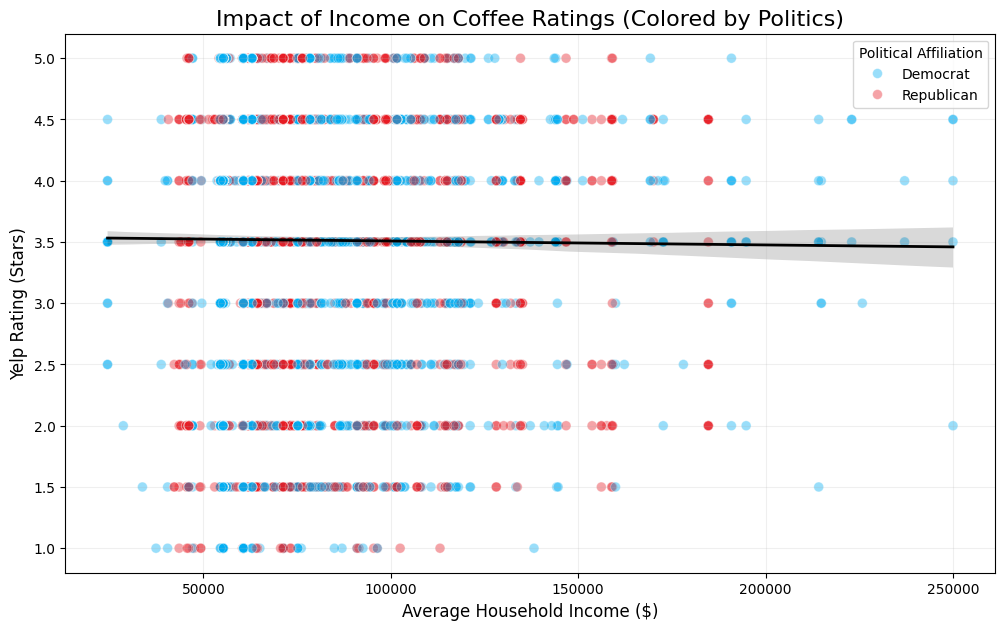

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set canvas size
plt.figure(figsize=(12, 7))

# 1. Define colors: professional political party colors
# Democrat in deep blue, Republican in deep red
party_colors = {'Democrat': '#00AEF3', 'Republican': '#E81B23'}

# 2. Draw scatter plot - points colored by 'party'
sns.scatterplot(
    x='salary',
    y='stars',
    data=df_clean,
    hue='party',           # color by political party
    palette=party_colors,  # use the red/blue colors defined above
    alpha=0.4,             # transparency at 0.4 to avoid overplotting
    s=50                   # point size
)

# 3. Draw regression line - one overall trend line
sns.regplot(
    x='salary',
    y='stars',
    data=df_clean,
    scatter=False,         # skip points here since they're already plotted above
    line_kws={'color': 'black', 'linewidth': 2} # black line for clarity
)

# Set title and axis labels
plt.title('Impact of Income on Coffee Ratings (Colored by Politics)', fontsize=16)
plt.xlabel('Average Household Income ($)', fontsize=12)
plt.ylabel('Yelp Rating (Stars)', fontsize=12)
plt.legend(title='Political Affiliation')
plt.grid(True, alpha=0.2)

# Display the chart
plt.show()

/tmp/ipykernel_14308/34097249.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Income_Group', y='stars', data=df_clean, palette="Blues")


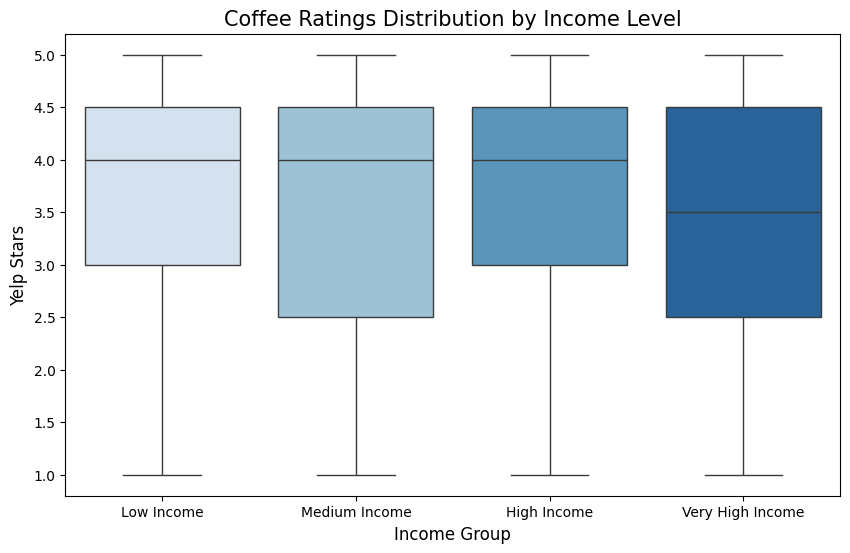

In [18]:
# 1. Split income into 4 equal groups (Quartiles)
# e.g. Low, Medium-Low, Medium-High, High
df_clean['Income_Group'] = pd.qcut(df_clean['salary'], q=4, labels=['Low Income', 'Medium Income', 'High Income', 'Very High Income'])

# 2. Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Income_Group', y='stars', data=df_clean, palette="Blues")

plt.title('Coffee Ratings Distribution by Income Level', fontsize=15)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Yelp Stars', fontsize=12)
plt.show()